In [ ]:
import pandas as pd
import numpy as np

from datetime import datetime

In [2]:
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (8, 2)

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# 1. Load & parse

In [3]:
ob = pd.read_csv('./eth-btc-orderbooks.csv', parse_dates=['timestamp'])

tr = pd.read_csv('./eth-btc-trades.csv', parse_dates=['timestamp'], dtype={'price': 'object', 'size': 'object'})

In [183]:
#ob.describe()

In [184]:
tr.describe()

,timestamp,price,size,side
count,845,845,845,845
unique,NaN,496,757,2
top,NaN,0.03987,0.00026058,BUY
freq,NaN,21,13,720
mean,2025-09-02 10:53:52.543195392+00:00,NaN,NaN,NaN
min,2025-09-01 00:02:57+00:00,NaN,NaN,NaN
25%,2025-09-01 17:29:09+00:00,NaN,NaN,NaN
50%,2025-09-02 10:35:57+00:00,NaN,NaN,NaN
75%,2025-09-03 05:01:16+00:00,NaN,NaN,NaN
max,2025-09-03 23:51:34+00:00,NaN,NaN,NaN


> \>85% of trades where on the buy side

In [185]:
720 / 845

0.8520710059171598

- create integer-type timestamps

In [4]:
ob['ts_ns'] = ob['timestamp'].apply( lambda x: int(x.timestamp()) * 10**9 + x.microsecond * 10**3 + x.nanosecond )

tr['ts_ns'] = tr['timestamp'].apply( lambda x: int(x.timestamp()) * 10**9 + x.microsecond * 10**3 + x.nanosecond )

## number of data points per day

In [ ]:
days_borders = [datetime(2025, 9, x).timestamp()*10**9 for x in [1,2,3]]

days_ob = np.searchsorted(days_borders, ob['ts_ns'])
print(f'Orderbook ts count by days:', end='\t')
for j in range(1, 4):
    print((days_ob == j).sum(), end = ', ')

print()

days_tr = np.searchsorted(days_borders, tr['ts_ns'])
print(f'Trades ts count by days:', end='\t')
for j in range(1, 4):
    print((days_tr == j).sum(), end = ', ')

Orderbook ts count by days:	64, 68, 56, 
Trades ts count by days:	273, 274, 298, 

## 1.2 Parse the prices

- Proper parsing to avoid floating point conversion errors

In [123]:
def convert_to_scaled_int(token, max_decimals=8):
    """
    Convert a decimal string to an integer scaled by 10^max_decimals.
    Example:
        token='0.04100829', max_decimals=8 -> integer = 4100829
    """
    if "." not in token:
        return int(token) * (10 ** max_decimals)
    whole, frac = token.split(".")
    frac = frac.ljust(max_decimals, "0")  # pad to uniform width
    return int(whole) * (10**max_decimals) + int(frac[:max_decimals])

In [124]:
arrasks = []
arrbids = []

In [125]:
NUM_RE = re.compile(r"\d+\.\d+|\d+")

In [126]:
for idx, row in ob.iterrows():
    
    prices_a = []
    sizes_a  = []
    prices_b = []
    sizes_b  = []
    

    ask_tokens = NUM_RE.findall(row["asks"])
    bid_tokens = NUM_RE.findall(row["bids"])

    # order: price, size, price, size, ...
    # so extract alternating pairs
    for t in ask_tokens[::2]:
        prices_a.append(convert_to_scaled_int(t))
    for t in ask_tokens[1::2]:
        sizes_a.append(convert_to_scaled_int(t))

    for t in bid_tokens[::2]:
        prices_b.append(convert_to_scaled_int(t))
    for t in bid_tokens[1::2]:
        sizes_b.append(convert_to_scaled_int(t))
        
    arrasks.append( np.vstack([np.array(prices_a),
                               np.array(sizes_a) ]) )
    arrbids.append( np.vstack([np.array(prices_b),
                               np.array(sizes_b) ]) )
    

In [127]:
asks = np.array(arrasks)
bids = np.array(arrbids)

In [128]:
asks.shape, bids.shape

((188, 2, 50), (188, 2, 50))

## 1.3 Parse the trades

- discovered some exponent notation in trade sizes, adapting parsing to such cases

In [246]:
for j in range(845):
    if len(NUM_RE.findall(tr["size"][j]))  != 1:
        print('id: ', j, ' size: ', tr["size"][j] )

id:  226  size:  1.901e-05
id:  228  size:  2.37e-06
id:  252  size:  8.742e-05
id:  385  size:  1.309e-05
id:  698  size:  2.09e-06
id:  700  size:  8.2e-07
id:  702  size:  5.6e-07
id:  745  size:  5.333e-05
id:  758  size:  1.174e-05


In [ ]:
def to_plain_decimal(number: str) -> str:
    mantissa, _, exponent = number.lower().partition('e')
    exponent = int(exponent or 0)

    sign = ''
    if mantissa[0] in '+-':
        sign = '-' if mantissa[0] == '-' else ''
        mantissa = mantissa[1:]

    if '.' in mantissa:
        integer_part, fractional_part = mantissa.split('.', 1)
    else:
        integer_part, fractional_part = mantissa, ''

    digits = integer_part + fractional_part
    decimal_pos = len(integer_part) + exponent

    if decimal_pos <= 0:
        digits = '0' * (-decimal_pos) + digits
        decimal_pos = 0
    elif decimal_pos >= len(digits):
        digits = digits + '0' * (decimal_pos - len(digits))

    integer = digits[:decimal_pos] or '0'
    fractional = digits[decimal_pos:]
    fractional = fractional.rstrip('0')
    result = integer if not fractional else f"{integer}.{fractional}"
    return sign + result

#to_plain_decimal('1.901e-05')

In [255]:
tr_sizes = []
tr_price = []

In [176]:
NUM_RE = re.compile(r"\d+\.\d+|\d+")

In [256]:
for idx, row in tr.iterrows():
    
    price_ = NUM_RE.findall(row["price"])
    size_ = NUM_RE.findall(row["size"])
    
    if len(size_) != 1:
        size_ = [to_plain_decimal(row['size'])]
    
    tr_price.append(convert_to_scaled_int(price_[0]))
    tr_sizes.append(convert_to_scaled_int(size_[0]))
    

In [341]:
tr_sizes = np.array(tr_sizes)
tr_price = np.array(tr_price)

In [491]:
#tr_price.shape, tr_price.shape

- check that there are no exponent representations in orderbook

In [221]:
for j in range(188):
    
    ea = ob['asks'][j].find('e-')
    eb = ob['bids'][j].find('e-')
    
    if ea != -1:
        print(j, 'a')
    if eb != -1:
        print(j, 'b')

# 2. Analysis

## 2.1 check ts distribution

- temporal distribution does not show significant clustering

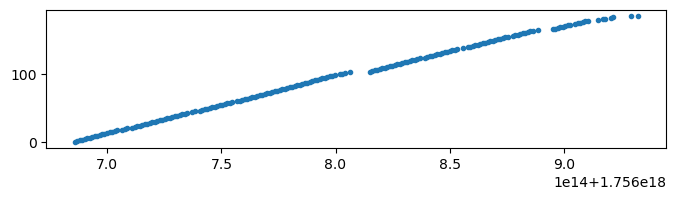

In [165]:
plt.plot(ob['ts_ns'], np.arange(len(ob['ts_ns'])), marker = '.', ls = '');

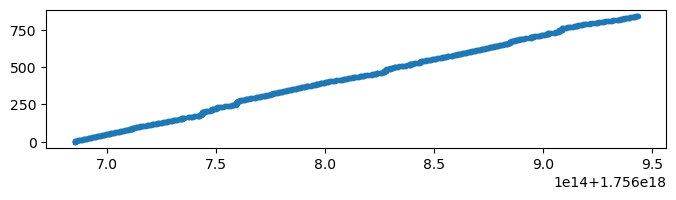

In [166]:
plt.plot(tr['ts_ns'], np.arange(len(tr['ts_ns'])), marker = '.', ls = '');

## 2.2 check orderbook prices ordering

- asks increasing, bids decreasing

In [492]:
np.all (np.diff(asks[:, 0,:], axis = 1) > 0 ), np.all (np.diff(bids[:, 0,:], axis = 1) < 0 )

(True, True)

## 2.3 plot the prices over time

- > this plot shows the unnatural behaviour of trades prices

In [327]:
tr['bool_side'] = tr['side'] == 'BUY'

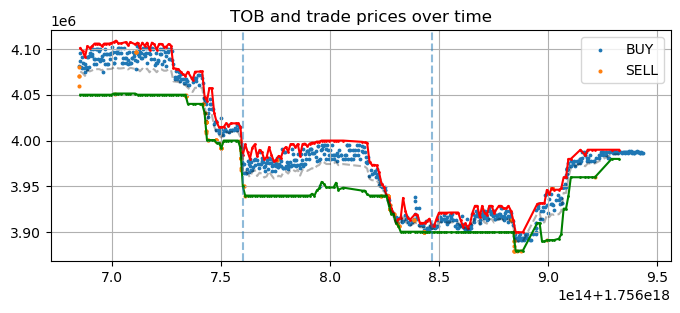

In [773]:
plt.figure(figsize=(8, 3))
# asks and bids
plt.plot(ob['ts_ns'], asks[:, 0, 0], marker = '.', ms = 2, color = 'r')
plt.plot(ob['ts_ns'], bids[:, 0, 0], marker = '.', ms = 2, color = 'g')
plt.plot(ob['ts_ns'], (bids[:, 0, 0]+asks[:, 0, 0])/2, ls='--', color = 'k', alpha = 0.3)

# day borders lines
plt.axvline(datetime(2025, 9, 2).timestamp()*10**9, ls = '--', alpha = 0.5)
plt.axvline(datetime(2025, 9, 3).timestamp()*10**9, ls = '--', alpha = 0.5)

#plt.plot(tr['ts_ns'], tr_price,  marker = '.', ms = 2, ls = '')
# colors = np.where(tr['side'] == 'BUY', 'tab:blue', 'tab:orange')
# plt.scatter(tr['ts_ns'], tr_price, c=colors, s=9, marker='.', )

buy_mask = tr['bool_side']
sell_mask = ~buy_mask
plt.scatter(tr['ts_ns'][buy_mask],  tr_price[buy_mask],
            c='tab:blue', s=12, marker='.', label='BUY')
plt.scatter(tr['ts_ns'][sell_mask], tr_price[sell_mask],
            c='tab:orange', s=15, marker='.', label='SELL')

plt.legend()

plt.grid(True)
plt.title('TOB and trade prices over time')
plt.savefig('./img/2_3_prices_vs_time')
plt.show()

## 2.4 plot cumulative orderbook shape

In [745]:
def plot_depth_one_fig(
    asks,
    bids,
    max_levels=None,
    normalize=True,
    alpha=0.05,
    cmap_name='cividis',
    figsize=(8, 2.5)
):
    """
    Plot a single figure overlaying many piecewise-linear depth curves.

    Inputs (all np.ndarrays):
      - ask_prices: (n_samples, n_asks), best ask at index 0, deeper asks at higher indices
      - ask_vols:   (n_samples, n_asks), volumes for asks
      - bid_prices: (n_samples, n_bids), best bid at index 0, deeper bids at higher indices
      - bid_vols:   (n_samples, n_bids), volumes for bids

    No y, no tick_size; x-axis is price distance from mid.
    """
    
    ask_prices = asks[:, 0, :]
    ask_vols = asks[:, 1, :]
    bid_prices = bids[:, 0, :]
    bid_vols = bids[:, 1, :]
    
    n_samples, n_asks = ask_prices.shape
    _, n_bids = bid_prices.shape
    
    if max_levels is None:
        max_levels_asks = n_asks
        max_levels_bids = n_bids
    else:
        max_levels_asks = min(max_levels, n_asks)
        max_levels_bids = min(max_levels, n_bids)
    
    ask_best = ask_prices[:, 0]
    bid_best = bid_prices[:, 0]
    mid = (ask_best + bid_best) / 2.0

    # cumulative volumes (best -> deep)
    ask_cum = np.cumsum(ask_vols, axis=1)
    bid_cum = np.cumsum(bid_vols, axis=1)

    total = (ask_cum[:, -1] + bid_cum[:, -1]).reshape(-1, 1)
    #total = np.where(total == 0, 1.0, total)  # avoid div-by-zero
    if not normalize:
        total = np.ones_like(total)
    ask_cum_norm = ask_cum / total
    bid_cum_norm = bid_cum / total
    
    # colors by sample index
    cmap = plt.get_cmap(cmap_name)
    norm = Normalize(vmin=0, vmax=max(1, n_samples - 1))
    sm = ScalarMappable(norm=norm, cmap=cmap)
    
    fig, ax = plt.subplots(figsize=figsize)

    for i in range(n_samples):
        # distances from mid in price units
        # bids are left of mid (negative), asks are right (positive)
        bid_offsets = bid_prices[i, :max_levels_bids] - mid[i]
        ask_offsets = ask_prices[i, :max_levels_asks] - mid[i]
        
        bid_offsets = bid_offsets  # already < 0 if bids < mid
        # asks already > mid, so positive

        color = cmap(norm(i))

        if max_levels_bids >= 2:
            ax.plot(bid_offsets, bid_cum_norm[i, :max_levels_bids],
                    color=color, alpha=alpha, linewidth=1)

        if max_levels_asks >= 2:
            ax.plot(ask_offsets, ask_cum_norm[i, :max_levels_asks],
                    color=color, alpha=alpha, linewidth=1)
    if normalize:
        ax.set_ylim(0, 0.9)
        ax.set_ylabel("Cumulative vol / total")
    else:
        ax.set_ylabel("Cumulative vol")
        
    ax.set_xlabel("Distance from mid (price units), bids left (negative), asks right (positive)")
    title = f"Cumulative depth curves (n={n_samples})"
    if normalize:
        title+='; normalized scale'
    else:
        title+='; raw scale'
    ax.set_title(title)
    #ax.set_yscale('symlog')

    ax.axvline(0, color='k', linewidth=0.5)

    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Sample index")

    plt.tight_layout()
    if normalize:
        plt.savefig('./img/2_4')
    plt.show()

- > This plot shows heavy imbalance towards the BUY side, which is shifting with time, most likely due to surface levels on that side being depleted, and deeper levels coming to surface. 

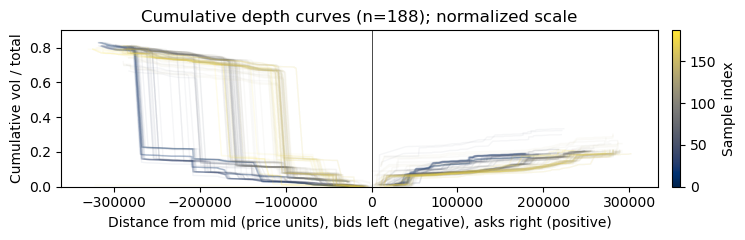

In [746]:
plot_depth_one_fig(asks, bids)

In [497]:
#plot_depth_one_fig(asks, bids, max_levels=10)

- Non-normalized version (raw volumes scale) for a subsample of data. Explanation below

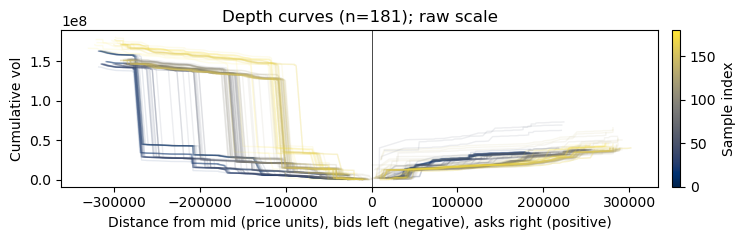

In [499]:
plot_depth_one_fig(asks[:181], bids[:181], alpha = 0.1, normalize=False)

- > abnormal volume spike on ask side at TOB at point 182. The nature of that extreme outlier (>2 orders of magnitude) is unclear

In [353]:
ask_cum = np.cumsum(asks[:, 1, :], axis = 1)

bid_cum = np.cumsum(bids[:, 1, :], axis = 1)

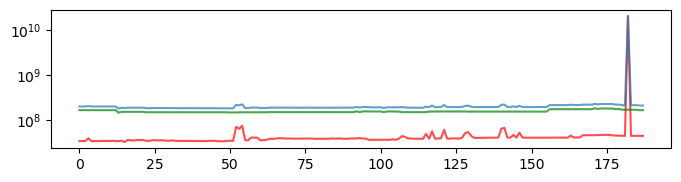

In [379]:
plt.figure()
plt.plot(ask_cum[:, -1], c = 'r', alpha = 0.7)
plt.plot(bid_cum[:, -1], c = 'g', alpha = 0.7)
plt.plot(ask_cum[:, -1]+bid_cum[:, -1], alpha = 0.7)

plt.yscale('symlog')
plt.show()

- Raw values:

In [400]:
ask_cum[182, -1]

20010093452

In [409]:
asks[182, 1, :4]

array([19966500000,      251800,     1389099,      570829], dtype=int64)

In [402]:
ob.iloc[182]

timestamp                  2025-09-03 16:33:30.943424800+00:00
asks         [{'price': 0.03984, 'size': 199.665}, {'price'...
bids         [{'price': 0.0396, 'size': 0.00528512}, {'pric...
ts_ns                                      1756917210943424800
Name: 182, dtype: object

##  2.5 naive check for opposite side adjacent trades

- > Conclusion: no obvious matching opposite-side trade pairs found

In [439]:
df = tr[['ts_ns', 'side']].copy()
#df = df.sort_values('ts_ns', kind='mergesort').reset_index(drop=True)

# build arrays
ts = df['ts_ns'].values
sides = df['side'].values

# compare each trade with the next one (or use rolling window >1 if needed)
dt = ts[1:] - ts[:-1]
dsize = np.abs(tr_sizes[1:] - tr_sizes[:-1])
dprice = np.abs(tr_price[1:] - tr_price[:-1])
opposite = (sides[1:] != sides[:-1])

# thresholds (adjust to taste)
max_time_ns = 100_000_000    #
max_size_diff = 1000       # volume tolerance
#max_price_diff = 1.0       # optional

mask = (dt <= max_time_ns) & (dsize <= max_size_diff) & opposite #& (dprice <= max_price_diff)

suspect_pairs = pd.DataFrame({
    'idx_a': np.where(mask)[0],
    'idx_b': np.where(mask)[0] + 1,
    'ts_a': ts[:-1][mask],
    'ts_b': ts[1:][mask],
    'size_a': tr_sizes[:-1][mask],
    'size_b': tr_sizes[1:][mask],
    'price_a': tr_price[:-1][mask],
    'price_b': tr_price[1:][mask],
    'side_a': sides[:-1][mask],
    'side_b': sides[1:][mask],
    'dt_ns': dt[mask]
})

In [440]:
suspect_pairs

,idx_a,idx_b,ts_a,ts_b,size_a,size_b,price_a,price_b,side_a,side_b,dt_ns


- same but with aggregating same-ts trades

In [454]:
# sort once so tr['ts_ns'] is nondecreasing
#order = np.argsort(tr['ts_ns'], kind='mergesort')
ts = tr['ts_ns'].values#[order]
sizes = tr_sizes#[order]
prices = tr_price#[order]
sides = tr['side'].values#[order]

# find block boundaries of equal timestamps
block_start = np.r_[0, np.flatnonzero(ts[1:] != ts[:-1])]
block_end = np.r_[block_start[1:], len(ts)]  # exclusive

pairs = []

size_tol = 1000
price_tol = 1
time_tol = 100_000_000

for start, end in zip(block_start, block_end):
    # block [start:end) shares same timestamp
    # compare every trade in this block with the first trade after the block
    if end == len(ts):
        continue  # nothing after final block

    next_idx = end  # first trade with a different timestamp
    dt = ts[next_idx] - ts[start]  # same for entire block
    
    if end - start >= 2:
        for i in range(start, end):
            for next_idx in range(start+1, end):
                same_ts_mask = (sides[i] != sides[next_idx]) \
                               and abs(sizes[i] - sizes[next_idx]) <= size_tol \
                               and abs(prices[i] - prices[next_idx]) <= price_tol \
                               and dt <= time_tol

                if same_ts_mask:
                    pairs.append({
                        'idx_a': order[i],
                        'idx_b': order[next_idx],
                        'ts_a': ts[i],
                        'ts_b': ts[next_idx],
                        'size_a': sizes[i],
                        'size_b': sizes[next_idx],
                        'price_a': prices[i],
                        'price_b': prices[next_idx],
                        'side_a': sides[i],
                        'side_b': sides[next_idx],
                        'dt_ns': dt
                    })



suspect_pairs = pd.DataFrame(pairs)

In [455]:
suspect_pairs

""


In [461]:
tr['ts_ns'].nunique()

754

## 2.6 time diff check

- > Conclusions:  
> for bids: almost 69% of points with no changes at all  
> for asks: around 44% of points where changes occur only at TOB level

In [525]:
diff_bids = np.diff(bids, axis=0)
diff_asks = np.diff(asks, axis=0)

### bids

- number of points where price levels don't change

In [516]:
((diff_bids[:, 0] != 0).sum(axis=1) == 0).sum() 

135

In [579]:
# percentage
"%.2f%%" % (135/187 * 100)

'72.19%'

- number of points where volumes don't change (subset of the above)

In [536]:
((diff_bids[:, 1] != 0).sum(axis=1) == 0).sum() 

119

- number of points where volumes and prices didn't change

In [551]:
(((diff_bids[:, 0] != 0).sum(axis=1) == 0) & ((diff_bids[:, 1] != 0).sum(axis=1) == 0)).sum()

119

In [580]:
# percentage
"%.2f%%" % (129/187 * 100)

'68.98%'

### asks

- number of points where all level data changed only at TOB

In [562]:
(((diff_asks[:, 1] != 0).sum(axis=1) == 1) & ((diff_asks[:, 1] != 0).argmax(axis = 1) == 0) & \
 ((diff_asks[:, 0] != 0).sum(axis=1) == 1) & ((diff_asks[:, 0] != 0).argmax(axis = 1) == 0) ).sum()

83

In [581]:
# percentage
"%.2f%%" % (83/187 * 100)

'44.39%'

- number of points where volumes changed only on TOB

In [556]:
(((diff_asks[:, 1] != 0).sum(axis=1) == 1) & ((diff_asks[:, 1] != 0).argmax(axis = 1) == 0)).sum()

99

- number of points where prices changed only on TOB

In [561]:
(((diff_asks[:, 0] != 0).sum(axis=1) == 1) & ((diff_asks[:, 0] != 0).argmax(axis = 1) == 0)).sum()

103

In [587]:
#(ob['bids'][1:].values == ob['bids'][:-1].values).sum()

## 2.7 round-volume trades

- > The presence of round-volume trades is insignificant

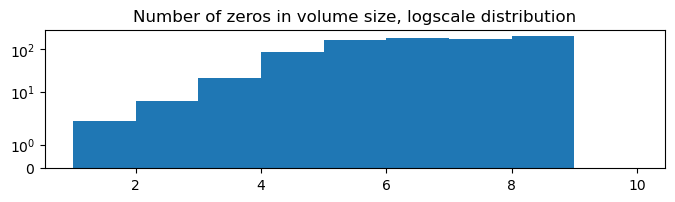

In [490]:
plt.hist( [len(x) - x.count('0')  for x in tr_sizes.astype(str)], bins = np.arange(1, 11) )
plt.yscale('symlog')
plt.title('Number of zeros in volume size, logscale distribution');

- A couple of granular examples

In [482]:
# smallest non-zero number cases
np.sort([len(x) - x.count('0')  for x in tr_sizes.astype(str)])[:10]

array([1, 1, 2, 2, 2, 2, 2, 2, 3, 3])

In [483]:
# specific ids
np.argsort([len(x) - x.count('0')  for x in tr_sizes.astype(str)])[:10]

array([230, 250, 776, 251, 698, 700, 702, 661, 333, 385], dtype=int64)

In [485]:
tr_sizes[230], tr_sizes[250], tr_sizes[776], tr_sizes[251]

(30000, 400000, 100050, 260000)

## 2.8 Volume histograms

### ____ trades

In [613]:
#plt.hist(tr_sizes, bins = 64);

In [621]:
#np.logspace(4, 11, 71)

In [627]:
# plt.hist(tr_sizes, bins = np.logspace(4, 11, 71));
# plt.xscale('log')
# plt.title('x logscale, trade size');

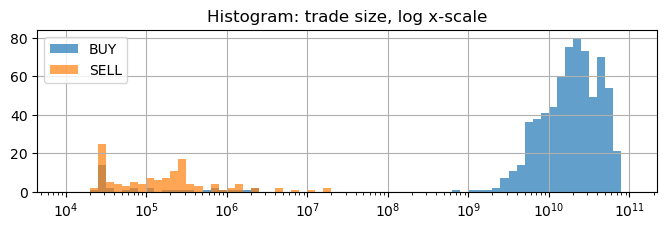

In [765]:
plt.figure(figsize=(8, 2.1))
plt.hist(tr_sizes[tr['side'] == 'BUY'],  bins = np.logspace(4, 11, 71), alpha = 0.7, label='BUY');
plt.hist(tr_sizes[tr['side'] == 'SELL'], bins = np.logspace(4, 11, 71), alpha = 0.7, label='SELL');
plt.xscale('log')
plt.grid(True)
plt.legend()
plt.title('Histogram: trade size, log x-scale')
plt.savefig('./img/2_8_tr');

### ____ asks

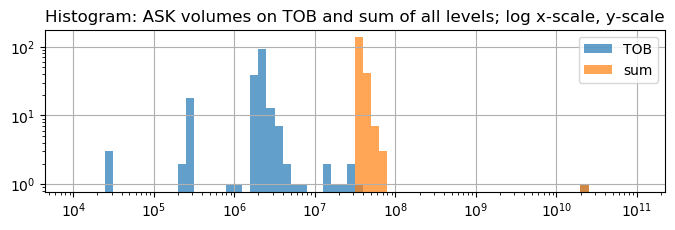

In [767]:
plt.figure(figsize=(8, 2.1))
plt.hist(asks[:, 1, 0], bins = np.logspace(4, 11, 71), alpha = 0.7, label='TOB');
plt.hist(asks[:, 1, :].sum(axis=1), bins = np.logspace(4, 11, 71), alpha = 0.7, label='sum');
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.title('Histogram: ASK volumes on TOB and sum of all levels; log x-scale, y-scale')
plt.savefig('./img/2_8_ask');

In [710]:
# plt.hist(asks[:, 1, 5], bins = np.logspace(4, 8, 41));
# plt.xscale('log')
# plt.yscale('log')

In [750]:
# plt.hist(asks[:, 1, :].sum(axis=1), bins = np.logspace(4, 11, 71));
# plt.xscale('log')
# plt.yscale('log')
# plt.title('ask volumes sum all levels (50); log x-scale');

### ____ bids

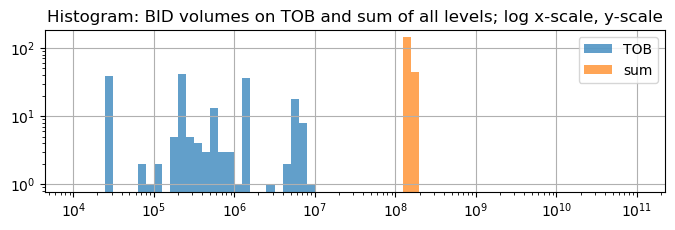

In [769]:
plt.figure(figsize=(8, 2.1))
plt.hist(bids[:, 1, 0], bins = np.logspace(4, 11, 71), alpha = 0.7, label='TOB');
plt.hist(bids[:, 1, :].sum(axis=1), bins = np.logspace(4, 11, 71), alpha = 0.7, label='sum');
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.title('Histogram: BID volumes on TOB and sum of all levels; log x-scale, y-scale')
plt.savefig('./img/2_8_bid');

In [764]:
# plt.hist(bids[:, 1, :].sum(axis=1), bins = np.logspace(4, 11, 71));
# plt.xscale('log')
# plt.yscale('log')
# plt.title('bid volumes sum all levels (50); log x-scale');

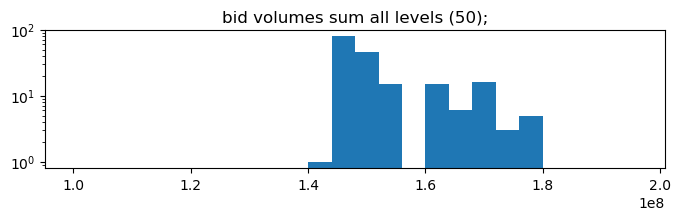

In [728]:
plt.hist(bids[:, 1, :].sum(axis=1), bins = np.arange(10**8, 2*10**8, 4*10**6));
#plt.xscale('log')
plt.yscale('log')
plt.title('bid volumes sum all levels (50);');

In [729]:
# plt.plot(bids[:, 1, :].sum(axis=1))
# plt.yscale('symlog');

## 2.9 Syncing trades to OB; price impact of trades

In [632]:
buy_mask = tr['side'] == 'BUY'

sell_mask = ~buy_mask

- time syncing

In [674]:
sync = np.searchsorted(ob['ts_ns'], tr['ts_ns']) - 1

(first few trades precede first OB tick:)

In [652]:
(tr['ts_ns'] < ob['ts_ns'][0]).sum()

6

In [676]:
sync[:6] = 0

- amount of trades that follow each OB update

In [678]:
trades_per_book = np.zeros_like(ob['ts_ns'], dtype=int)
for i in sync[6:]:
    trades_per_book[i] += 1

In [680]:
#trades_per_book

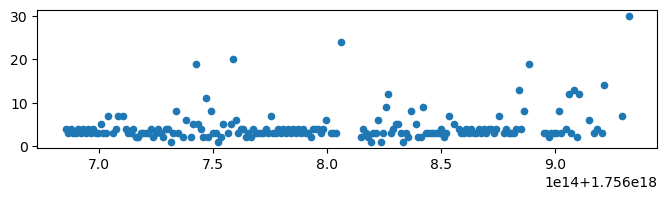

In [683]:
plt.plot(ob['ts_ns'], trades_per_book, marker = '.', ms = 9, ls = '');

In [663]:
#np.diff(ob['ts_ns'])

Text(0, 0.5, 'timespan until next tick')

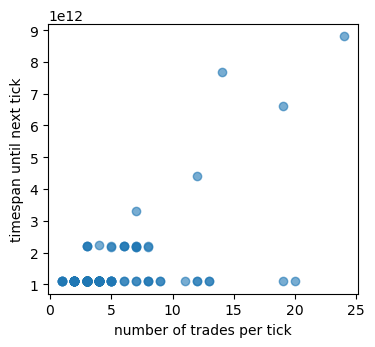

In [672]:
plt.figure(figsize=(4,3.5))
plt.scatter( trades_per_book[:-1], np.diff(ob['ts_ns']), alpha = 0.6 )
#plt.title('x: number of trades per tick; y: timespan until next tick');
plt.xlabel('number of trades per tick')
plt.ylabel('timespan until next tick')
#plt.yscale('log')

In [686]:
#buy_mask[:8]

### price impact

In [ ]:
ask_cum = np.cumsum(asks[:, 1, :], axis = 1)

bid_cum = np.cumsum(bids[:, 1, :], axis = 1)

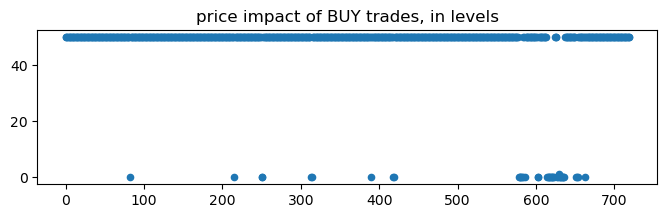

In [770]:
plt.plot( (tr_sizes[buy_mask].reshape(-1, 1) > ask_cum[sync][buy_mask]).sum(axis=1), marker = '.', ms = 9, ls = '' );
plt.title('price impact of BUY trades, in levels')
plt.savefig('./img/2_9');

In [696]:
pd.Series((tr_sizes[buy_mask].reshape(-1, 1) > ask_cum[sync][buy_mask]).sum(axis=1)).value_counts()

50    678
0      41
1       1
Name: count, dtype: int64

- > Even if we check the impact on the other side (bids), it's still absurd

In [702]:
pd.Series((tr_sizes[buy_mask].reshape(-1, 1) > bid_cum[sync][buy_mask]).sum(axis=1)).value_counts()

50    679
0      34
1       3
4       2
3       2
Name: count, dtype: int64

In [701]:
#(tr_sizes[buy_mask].reshape(-1, 1) > bid_cum[sync][buy_mask]).sum(axis=1)

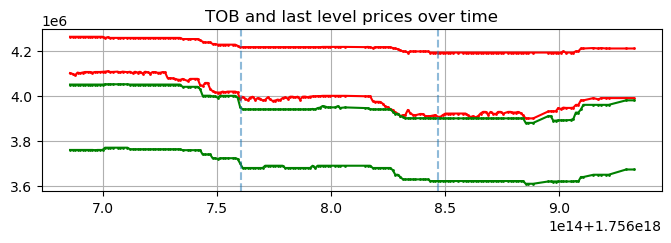

In [772]:
plt.figure(figsize=(8, 2.1))
# asks and bids
plt.plot(ob['ts_ns'], asks[:, 0, 0], marker = '.', ms = 2, color = 'r')
plt.plot(ob['ts_ns'], asks[:, 0, -1], marker = '.', ms = 2, color = 'r')
plt.plot(ob['ts_ns'], bids[:, 0, 0], marker = '.', ms = 2, color = 'g')
plt.plot(ob['ts_ns'], bids[:, 0, -1], marker = '.', ms = 2, color = 'g')

# day borders lines
plt.axvline(datetime(2025, 9, 2).timestamp()*10**9, ls = '--', alpha = 0.5)
plt.axvline(datetime(2025, 9, 3).timestamp()*10**9, ls = '--', alpha = 0.5)

plt.grid(True)
plt.title('TOB and last level prices over time')
plt.savefig('./img/2_9_1')
plt.show()